<a href="https://colab.research.google.com/github/pipioinc/syncnet_python/blob/master/mypipio_CAE_%2B_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipio CAE

Conditional convolutional renderer:
* Conditions like voice, avatar pose, ...
* Voice from VOCA/Neural Voice puppetry/Wav2Lip ...


In order to allow Colaboratory to connect to your locally running Jupyter server, you'll need to perform the following steps.

Step 1: Install Jupyter
Install Jupyter on your local machine.

Step 2: Install and enable the jupyter_http_over_ws jupyter extension (one-time)
The jupyter_http_over_ws extension is authored by the Colaboratory team and available on GitHub.

pip install jupyter_http_over_ws
jupyter serverextension enable --py jupyter_http_over_ws
Step 3: Start server and authenticate
New notebook servers are started normally, though you will need to set a flag to explicitly trust WebSocket connections from the Colaboratory frontend.

```
jupyter notebook \
  --NotebookApp.allow_origin='https://colab.research.google.com' \
  --port=8888 \
  --NotebookApp.port_retries=0
```


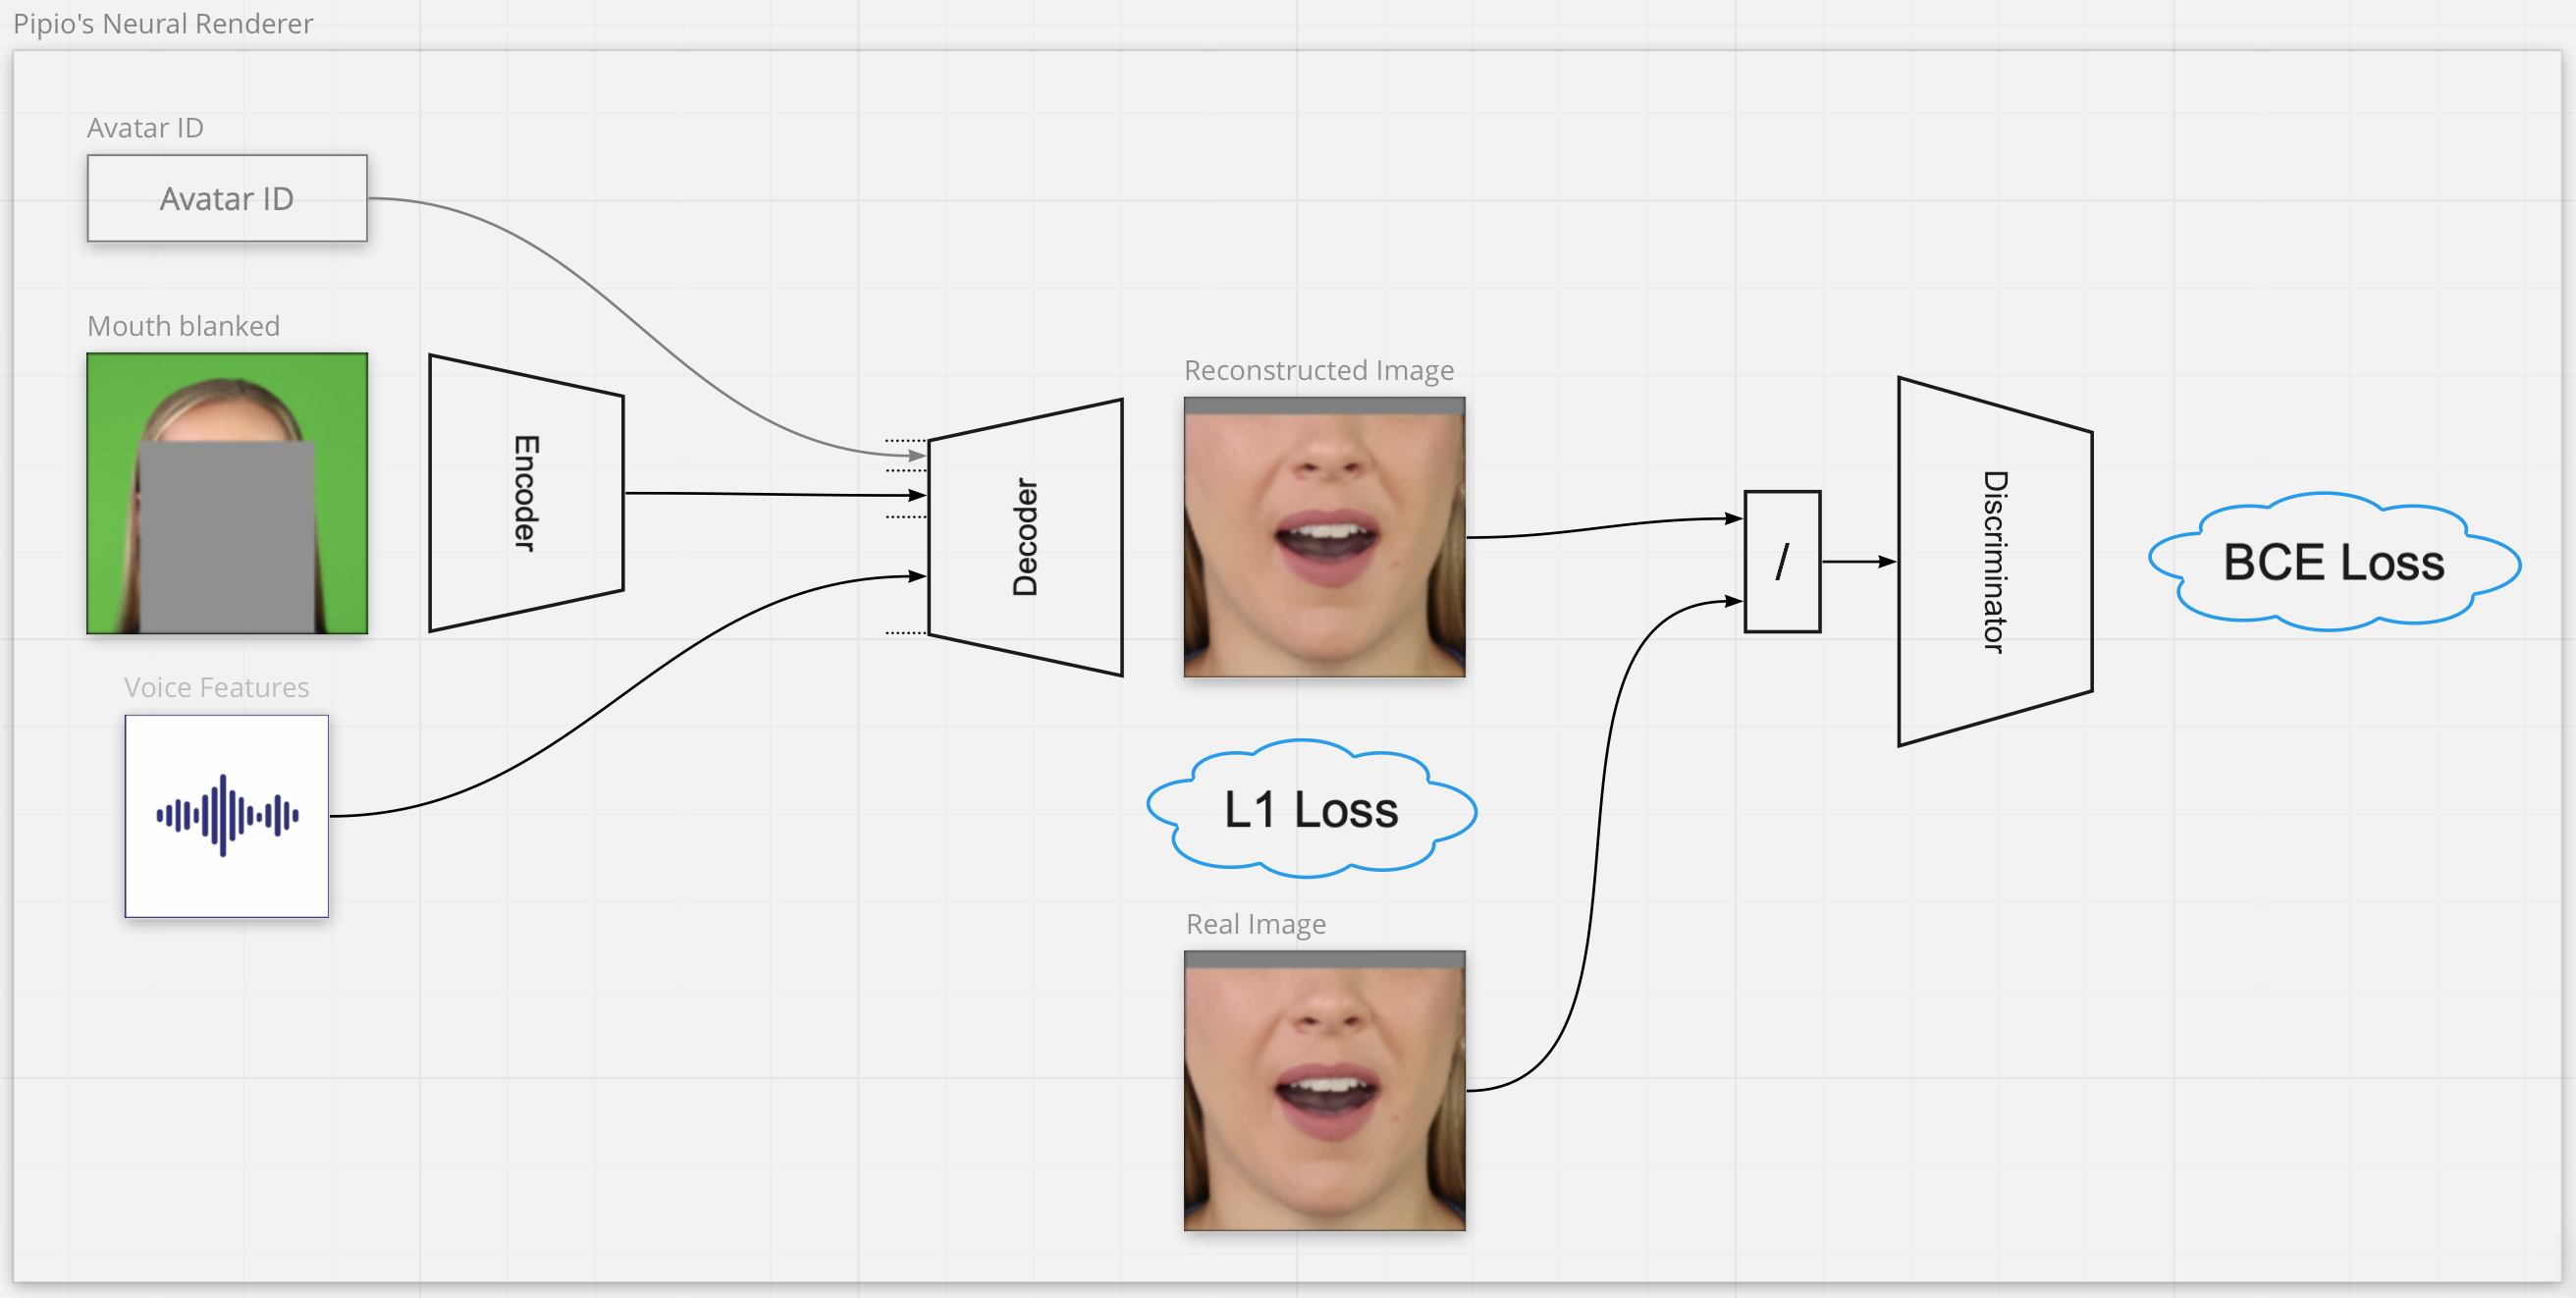

### Notes:
* Test if training data augmentation helps disentangle the head pose from the voice features...
* Pablo needs more training data! Test how much training data we need for the current rendering approach. We might need more training data the more the head moves around.
* The per-frame/appearance vector trick might be useful to reduce the training data requirement at the cost of reduced expressivity.
* ToDo: Try out an upscale and conv instead of transpose conv to see if it improves the image quality.
* ToDo: Reduce the size of the blanking on the pose frames to include a frame around the outside of the image to condition on neck, ears, etc.
* Specific outlier training samples could have high error and possibly cause blurring in the result... Consider throwing out bad frames?

In [ ]:
gpu_idx = 0

In [ ]:
# Check what GPU I got...

import torch

print(f"Torch version is {torch.__version__}")
print(f"Torch CUDA version is {torch.version.cuda}")

if torch.cuda.is_available():
    device = torch.device(f"cuda:{gpu_idx}")
    print(f"torch.cuda.device_count() = {torch.cuda.device_count()}")
    print(f"torch.cuda.get_device_name({gpu_idx}) = {torch.cuda.get_device_name(gpu_idx)}")
else:
    print(f"torch.cuda.is_available() = {torch.cuda.is_available()}")
    device = torch.device("cpu")

Torch version is 1.10.2+cu113
Torch CUDA version is 11.3
torch.cuda.device_count() = 2
torch.cuda.get_device_name(0) = NVIDIA RTX A4000


In [ ]:
# Test the GPU if needed. No errors mean the GPU is likely working ok.

import torch
import torch.optim as optim

model = torch.nn.Linear(5, 2)

#Initialize optimizer
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

model.to(device)
data = torch.randn(1, 5, device=device)
out = model(data)
out.mean().backward()

optimizer.step()
optimizer.zero_grad()

print("GPU seems to be working.")

GPU seems to be working.


In [ ]:
# Check what CPU I got...

import psutil

cpu_count = psutil.cpu_count()
print(f"cpu_count = {cpu_count}")

cpu_count = 20


In [ ]:
# !cat /proc/cpuinfo

In [ ]:
from __future__ import print_function
#%matplotlib inline
import argparse
import os
import time
import random
import json

from collections import OrderedDict
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.utils.data import Dataset

import torchvision.utils as vutils

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from IPython.display import HTML
from IPython.display import clear_output

# Weights and Biases

In [ ]:
!pip install wandb

You should consider upgrading via the '/home/bduvenhage/dev/colab_server/.pyenv/bin/python -m pip install --upgrade pip' command.


In [ ]:
import wandb
wandb.login()

# Use the terminal to do 'wandb login'. The above command hangs often!

wandb: Currently logged in as: bernardt-duvenhage (use `wandb login --relogin` to force relogin)


True

# Training Data

In [ ]:
# If working on Colab:

# Mount your gdrive to get the input files from and save the results to.
from google.colab import drive
drive.mount("/content/gdrive")

dataset_root = "/content/gdrive/MyDrive/avatar_data"

In [ ]:
# If working locally:

dataset_root = "/home/bduvenhage/avatar_data"

In [ ]:
dataset_folder = 'mp'
dataset_name = 'rachel-604_0028-trimmed'

In [ ]:
print(f"{dataset_root}/{dataset_folder}/{dataset_name}")

/home/bduvenhage/avatar_data/mp/rachel-604_0028-trimmed


In [ ]:
from zipfile import ZipFile
import time
from tqdm import tqdm

def unzip(zip_file, path):
    """ Unzip a zip_file to path with progress bar. """
    with ZipFile(zip_file,"r") as zip_ref:
        for file in tqdm(iterable=zip_ref.namelist(), total=len(zip_ref.namelist())):
              zip_ref.extract(member=file, path=path)

# Conditional Auto Encoder

In [ ]:
wav2lip_zip = f"{dataset_root}/wav2lip_{dataset_name}.zip"

# Aligned & cropped training images. These images should be at least double the size of image_size.
img_zip = f"{dataset_root}/{dataset_folder}/aligned_{dataset_name}_png.zip"

In [ ]:
print(wav2lip_zip)
print(img_zip)

/home/bduvenhage/avatar_data/wav2lip_rachel-604_0028-trimmed.zip
/home/bduvenhage/avatar_data/mp/aligned_rachel-604_0028-trimmed_png.zip


In [ ]:
flavour = ""  # Useful when training multiple models (with for example different hyper-params) from the same dataset e.g. "_low_lr"

In [ ]:
# If working on Colab:

artifact_root = f"/content/gdrive/MyDrive/avatar_artifacts_working/{dataset_name}{flavour}"

In [ ]:
# If working locally:

artifact_root = f"/media/bduvenhage/Data/avatar_artifacts_working/{dataset_name}{flavour}"

In [ ]:
print(artifact_root)

/media/bduvenhage/Data/avatar_artifacts_working/rachel-604_0028-trimmed


In [ ]:
!mkdir $artifact_root

mkdir: cannot create directory ‘/media/bduvenhage/Data/avatar_artifacts_working/rachel-604_0028-trimmed’: File exists


In [ ]:
# Save the model config.
model_config = {
    "voice_input_nz": 512,
    "voice_input_seq_len": 5,
    "voice_enc_nz": 16,
    "mask_enc_nz": 16,
    "mask_enc_nf": 16,
    "img_dec_nf": 64,
    "img_disc_nf": 64,
    "image_size": 256,
    "cae_lr": 0.001,  # 0.0003
    "disc_lr": 0.001,  # 0.0003
    "beta1": 0.5,
}

with open(f"{artifact_root}/cae.json", "w") as f:
    json.dump(model_config, f)

In [ ]:
# 2. Note model config in wandb
wandb_config = model_config

In [ ]:
# 1. Start a new W&B run.
import wandb
wandb_run = wandb.init(project='pipio-cae',
           entity='bernardt-duvenhage',
           config=wandb_config,
           save_code = True)  # ,
           # resume='must',
           # id='26uva9ng')

wandb: wandb version 0.12.11 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade


In [ ]:
# Weight initialization code ...

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
# Discriminator to score the 'real'-ness of a face.

class Discriminator(nn.Module):
    def __init__(self, _nf, _image_size):
        super(Discriminator, self).__init__()

        module_list = [
                       # input is (3) x image_size x image_size
                       ('input', nn.Conv2d(in_channels=3,
                                           out_channels=_nf * 1,
                                           kernel_size=4, stride=2, padding=1, bias=False)),
                       # state size = (nf*1) x (_image_size>>1) x (_image_size>>1)
                       ('input_act', nn.LeakyReLU(0.2, inplace=True)),
        ]

        for i in range(1, _image_size.bit_length()-3):
          module_list.extend([
                              (f"disc_{_image_size>>(i+1)}", nn.Conv2d(in_channels=_nf * (2**(i-1)),
                                                                      out_channels=_nf * (2**i),
                                                                      kernel_size=4, stride=2, padding=1, bias=False)),
                              # state size = (nf*(2**i)) x (image_size>>(i+1)) x (image_size>>(i+1))
                              (f"disc_norm_{_image_size>>(i+1)}", nn.BatchNorm2d(_nf * (2**i))),
                              (f"disc_act_{_image_size>>(i+1)}", nn.LeakyReLU(0.2, inplace=True)),
          ])

        module_list.extend([
                            ('head', nn.Conv2d(in_channels=_nf * (2**(_image_size.bit_length()-4)),
                                               out_channels=1,
                                               kernel_size=4, stride=1, padding=0, bias=False)),
                            # state size = 1 x 1 x 1
                            ('head_act', nn.Sigmoid()),
        ])


        self._model = nn.Sequential(
            OrderedDict(module_list)
        )

    def forward(self, input):
        return self._model(input)

In [ ]:
# ImgEncoder code derived from the GAN discriminator:
# - Encodes the aligned 256x256 face image.

class ImgEncoder(nn.Module):
    def __init__(self, _nf, _nz):
        """
        :param _nf: Conv. net feature multiplier.
        :param _nz: The dimension of the output embedding.
        """
        super(ImgEncoder, self).__init__()

        self.main = nn.Sequential(
            # input is (3) x 256 x 256

            nn.Conv2d(in_channels=3, out_channels=_nf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (nf*1) x 128 x 128

            nn.Conv2d(in_channels=_nf, out_channels=_nf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(_nf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (nf*2) x 64 x 64

            nn.Conv2d(in_channels=_nf * 2, out_channels=_nf * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(_nf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (nf*4) x 32 x 32

            nn.Conv2d(in_channels=_nf * 4, out_channels=_nf * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(_nf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (nf*8) x 16 x 16

            nn.Conv2d(_nf * 8, _nf * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(_nf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (nf*16) x 8 x 8

            nn.Conv2d(_nf * 16, _nf * 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(_nf * 32),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (nf*32) x 4 x 4

            nn.Conv2d(_nf * 32, _nz, 4, 1, 0, bias=False),
            # state size. _nz x 1 x 1
        )

    def forward(self, mask_batch):
        batch_size = mask_batch.shape[0]
        mask_encoding_batch = self.main(mask_batch).view(batch_size, -1)
        return mask_encoding_batch


In [ ]:
# Decoder code derived from the GAN generator:
# - Renders the final image given the mask and audio conditions.

class Decoder(nn.Module):
    def __init__(self,
                 _nz, _nf, _image_size):
        """
        :param _nz: Dimension of input embedding.
        :param _nf: Conv. net feature multiplier.
        """
        super(Decoder, self).__init__()

        module_list = [
                       ('input', nn.ConvTranspose2d(in_channels=_nz,
                                                    out_channels=_nf * (2**(_image_size.bit_length()-4)),
                                                    kernel_size=4, stride=1, padding=0, bias=False)),
                       # state size = (nf*32) x 4 x 4 or (nf*64) x 4 x 4
                       ('input_norm', nn.BatchNorm2d(_nf * (2**(_image_size.bit_length()-4)))),
                       ('input_act', nn.LeakyReLU(0.1, inplace=True)),
        ]

        for i in range(_image_size.bit_length()-4, 0, -1):
          module_list.extend([
                              (f"deco_{_image_size>>i}", nn.ConvTranspose2d(in_channels=_nf * (2**i),
                                                                           out_channels=_nf * (2**(i-1)),
                                                                           kernel_size=4, stride=2, padding=1, bias=False)),
                              # state size = (nf*(2**(i-1))) x (image_size>>i) x (image_size>>i)
                              (f"deco_norm_{_image_size>>i}", nn.BatchNorm2d(_nf * (2**(i-1)))),
                              (f"deco_act_{_image_size>>i}", nn.LeakyReLU(0.1, inplace=True)),
          ])

        module_list.extend([
                            ('head', nn.ConvTranspose2d(in_channels=_nf,
                                                        out_channels=3,
                                                        kernel_size=4, stride=2, padding=1, bias=False)),
                            # state size = (3) x image_size x image_size
                            ('head_act', nn.Tanh()),
        ])

        self._model = nn.Sequential(
            OrderedDict(module_list)
        )

    def forward(self, input_batch):
        batch_size = input_batch.shape[0]
        input_batch = input_batch.view(batch_size, -1, 1, 1)
        return self._model(input_batch)




In [ ]:
class CAE(nn.Module):
    def __init__(self, model_config):
        super(CAE, self).__init__()

        self._voice_encoder = nn.Sequential(
            nn.Linear(model_config['voice_input_nz']*model_config['voice_input_seq_len'], 1024),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(1024, 1024),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(1024, model_config['voice_enc_nz']),
        )

        self._mask_encoder = ImgEncoder(model_config['mask_enc_nf'], model_config['mask_enc_nz'])
        self._mask_encoder.apply(weights_init)

        self._decoder = Decoder(model_config['voice_enc_nz'] + model_config['mask_enc_nz'],
                                    model_config['img_dec_nf'], model_config['image_size'])
        self._decoder.apply(weights_init)

    def mask_encode(self, mask_batch):
        mask_encoding_batch = self._mask_encoder(mask_batch)
        mask_encoding_batch = F.normalize(mask_encoding_batch)
        return mask_encoding_batch

    def voice_encode(self, voice_batch):
        batch_size = voice_batch.shape[0]
        voice_encoding_batch = self._voice_encoder(voice_batch.reshape(batch_size, -1))
        voice_encoding_batch = F.normalize(voice_encoding_batch)
        return voice_encoding_batch

    def decode(self, voice_encoding_batch, mask_encoding_batch):
        decoder_input_batch = torch.cat((voice_encoding_batch, mask_encoding_batch), 1)
        return self._decoder(decoder_input_batch)

    def forward(self, voice_batch, mask_batch):
        voice_encoding_batch = self.voice_encode(voice_batch)
        mask_encoding_batch = self.mask_encode(mask_batch)
        return self.decode(voice_encoding_batch, mask_encoding_batch), voice_encoding_batch, mask_encoding_batch


In [ ]:
# !pip install lpips

In [ ]:
# import lpips

In [ ]:
# reconstruction_loss_fn = nn.MSELoss()
reconstruction_loss_fn = nn.L1Loss()
# reconstruction_loss_fn = lpips.LPIPS(net='vgg').to(device)

# ToDo: Look at adding SSIM loss from https://github.com/francois-rozet/piqa

In [ ]:
ref_loss_fn = nn.L1Loss()

In [ ]:
# temporal_loss_fn = nn.L1Loss()

In [ ]:
import zipfile

zf_dict = {}  # type: Dict[str, ZipFile]

def _open_zf(zip_file_path):
    zf = zf_dict.get(zip_file_path)

    if zf is None:
        # Lazily load the zip file.
        zf = zipfile.ZipFile(zip_file_path, mode='r')
        zf_dict[zip_file_path] = zf
    return zf

def zf_num_members(zip_file_path):
    with zipfile.ZipFile(zip_file_path, mode='r') as zf:
        num_members = len(zf.namelist())
    return num_members

def zf_member(zip_file_path, member_name):
    zf = _open_zf(zip_file_path)
    return zf.open(member_name)

In [ ]:
from PIL import Image
from PIL import ImageFilter

import random
import zipfile
from itertools import repeat
import concurrent.futures


class CAEDataset(Dataset):
    def __init__(self,
                 img_zip,
                 image_size,
                 wav2lip_zip,
                 voice_input_seq_len, voice_input_nz,
                 num_samples: int,
                 cache_size: int):
        self._img_zip = img_zip
        self._image_size = image_size
        self._wav2lip_zip = wav2lip_zip
        self._voice_input_seq_len = voice_input_seq_len
        self._voice_input_nz = voice_input_nz

        self._num_samples = num_samples
        self._cache_size = min(cache_size, num_samples)

        dataset_mean = (0.5, 0.5, 0.5)
        dataset_std = (0.5, 0.5, 0.5)

        self._tensor_transform=transforms.Compose([transforms.ToTensor(),
                                                   transforms.Normalize(dataset_mean, dataset_std)])

        self._item_cache = {}

        if self._cache_size > 0:
          # A. Cache some or all of the data IN MAIN PROCESS. SLOW :-(
          # for item_idx in tqdm(range(self._num_samples)):
          #     _ = self.__getitem__(item_idx)
          # OR
          # B. Cache some or all of the data CONCURRENTLY. FAST :-)
          with concurrent.futures.ProcessPoolExecutor(max_workers=16) as executor:
              item_idx_list = list(range(self._num_samples))

              random.shuffle(item_idx_list)
              item_idx_list = item_idx_list[:self._cache_size]  # Only cache a random subset of size self._cache_size.

              item_list = list(
                  tqdm(
                      executor.map(CAEDataset.load_item, item_idx_list,
                                   repeat(self._img_zip), repeat(self._image_size),
                                   repeat(self._wav2lip_zip), repeat(self._voice_input_seq_len), repeat(self._voice_input_nz)),
                      total=len(item_idx_list),
                      desc=f"Caching {round(self._cache_size * 100.0 / self._num_samples, 2)}% of items."
                      )
                  )

              # Assemble the item_list result into a _item_cache
              self._item_cache = dict(zip(item_idx_list, item_list))

    def __len__(self):
        return self._num_samples

    @staticmethod
    def get_code_seq(frame_idx, dataset_zip, # frame_idx is 0-based.
                     voice_input_seq_len, voice_input_nz):
      voice_expr = np.zeros(shape=(voice_input_seq_len, voice_input_nz), dtype=np.float32)

      for seq_idx in range(voice_input_seq_len):
          _idx = frame_idx + seq_idx - (voice_input_seq_len//2)
          if _idx < 0:
              _idx_clamped = 0
          # elif _idx >= self._num_samples:
          #   _idx_clamped = self._num_samples-1
          else:
              _idx_clamped = _idx

          _expr = np.load(zf_member(dataset_zip, f"{_idx_clamped}.wav2lip.npy")).astype(np.float32).squeeze()  # wav2lip indexing is 0-based.

          # _expr = project_code(_expr, 5)

          voice_expr[seq_idx] = _expr

      return voice_expr

    @staticmethod
    def load_item(item_idx,
                  img_zip, image_size,
                  wav2lip_zip, voice_input_seq_len, voice_input_nz):
        aligned_img_resize_transform = transforms.Resize((image_size*2, image_size*2), interpolation=transforms.InterpolationMode.BOX)
        mask_resize_transform = transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.BOX)

        # The image features.
        aligned_img = Image.open(zf_member(img_zip, f"aligned_{str(item_idx).zfill(5)}.png"))

        if aligned_img.width != (image_size * 2):
          aligned_img = aligned_img_resize_transform(aligned_img)

        # The voice features.
        voice_expr = CAEDataset.get_code_seq(item_idx, wav2lip_zip, voice_input_seq_len, voice_input_nz)

        # Create the mask.
        img_masked = mask_resize_transform(aligned_img)
        # img_masked = img_masked.filter(ImageFilter.SMOOTH_MORE);  # Smooth the image to be masked to remove any fingerprinty noise. Porbably not needed.
        # img_masked.paste( (128, 128, 128), (0+48, 80, 256-48, 256))  # Mask out mouth and expression regions of face.
        # img_masked.paste( (128, 128, 128), (0+72, 88, 256-72, 256))  # Mask out mouth and expression regions of face.
        img_masked.paste( (128, 128, 128), (0, 0, 256, 256))  # Mask out mouth and expression regions of face.

        img = aligned_img  # .filter(ImageFilter.SHARPEN);  # Sharpen the training image to promote a sharper render!

        img = img.crop((image_size>>1, image_size, image_size*2 - (image_size>>1), image_size*2))  # Keep only chin to nose pixels.
        # img.paste( (128, 128, 128), (0, 0, image_size, image_size>>4))  # Mask out what remains of eyes in crop.

        return voice_expr, img_masked, img

    def __getitem__(self, item_idx):  # item_idx is zero based.
        item = self._item_cache.get(item_idx)

        if item is None:
            # Load item if not cached.
            item = CAEDataset.load_item(item_idx,
                                        self._img_zip, self._image_size,
                                        self._wav2lip_zip, self._voice_input_seq_len, self._voice_input_nz)

            if len(self._item_cache) < self._cache_size:
                self._item_cache[item_idx] = item

        voice_expr, img_masked, img = item

        img_masked_tensor = self._tensor_transform(img_masked)
        img_tensor = self._tensor_transform(img)

        return item_idx, voice_expr, img_masked_tensor, img_tensor


In [ ]:
import cv2
import uuid

# Note: Try for larger batch sizes. Original "UNSUPERVISED REPRESENTATION LEARNING WITH DEEP CONVOLUTIONAL GENERATIVE ADVERSARIAL NETWORKS", 2016,
# paper that uses batch norm used a batch size of 128.
batch_size = 32

num_workers = min(cpu_count, 8)
dataset_num_frames = zf_num_members(wav2lip_zip)
num_samples = dataset_num_frames - 5

# Create the dataset
dataset_cae = CAEDataset(
    img_zip=img_zip,
    image_size=model_config['image_size'],
    wav2lip_zip=wav2lip_zip,
    voice_input_seq_len=model_config['voice_input_seq_len'],
    voice_input_nz=model_config['voice_input_nz'],
    # num_samples=40500,  # kilo
    # num_samples=35830,  # sonal
    # num_samples=32250,  # rachel
    # num_samples=29970,  # mark
    # num_samples=35830,  # 38750  # james
    # num_samples=29000,  # ian
    # num_samples=27950,  # taylen
    num_samples=num_samples,
    cache_size=15000  # The number of samples we expect would fit in the amount of system RAM we have set aside per GPU.
    )

len_dataset_cae = len(dataset_cae)
num_validation_frames = int(len_dataset_cae * 0.1)

# Unsplit loader for inspecting the data:
dataloader_cae = torch.utils.data.DataLoader(dataset_cae, batch_size=batch_size, drop_last=True,
                                             shuffle=True,
                                             num_workers=num_workers)

# Split train val loader with shuffle:
train_dataset, val_dataset = torch.utils.data.random_split(dataset=dataset_cae,
                                                           lengths=[len_dataset_cae - num_validation_frames, num_validation_frames],
                                                           generator=torch.Generator().manual_seed(42))

train_dataloader_cae = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, drop_last=True,
                                                   shuffle=True,
                                                   num_workers=num_workers)
val_dataloader_cae = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, drop_last=True,
                                                 shuffle=True,  # Shuffle the val data to randomize the results preview.
                                                 num_workers=num_workers)


Caching 46.47% of items.: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15000/15000 [00:46<00:00, 320.56it/s]


voice_expr_batch.shape = torch.Size([32, 5, 512])


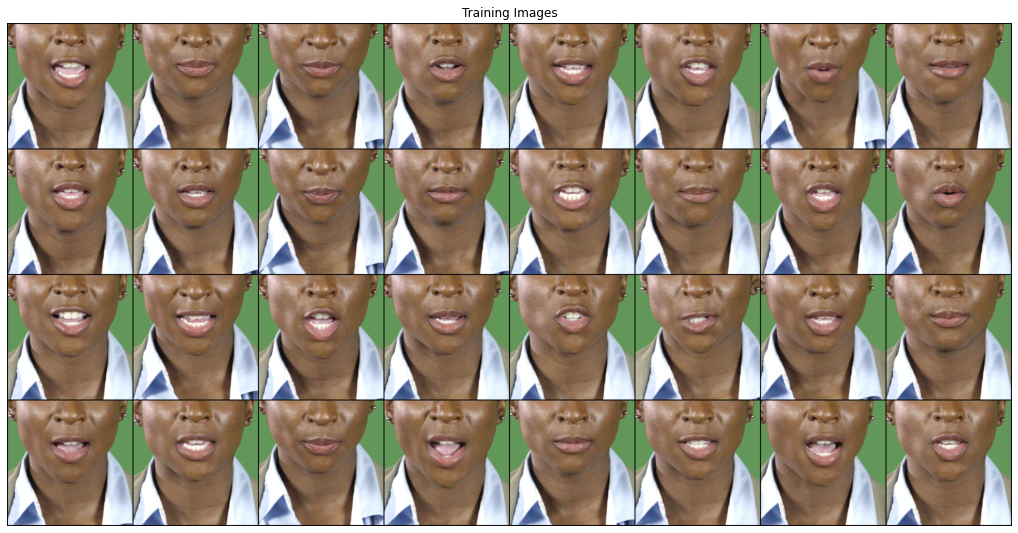

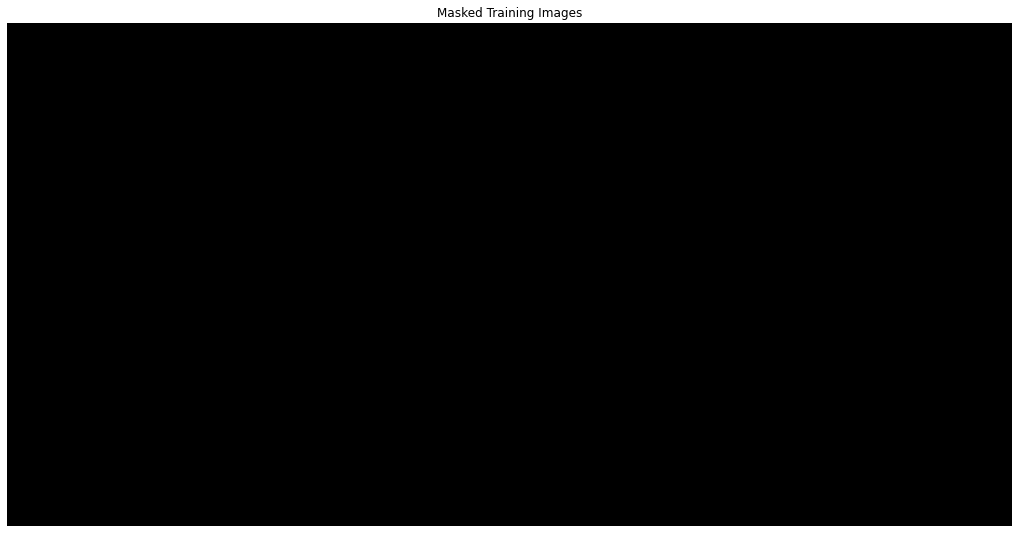

In [ ]:
data_iter = iter(dataloader_cae)
item_idx_batch, voice_expr_batch, img_masked_batch, img_batch = next(data_iter)

plt.figure(figsize=(18, 18))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(img_batch[:32], padding=2, normalize=True),(1,2,0)))

plt.figure(figsize=(18, 18))
plt.axis("off")
plt.title("Masked Training Images")
plt.imshow(np.transpose(vutils.make_grid(img_masked_batch[:32], padding=2, normalize=True),(1,2,0)))

print(f"voice_expr_batch.shape = {voice_expr_batch.shape}")

In [ ]:
# # See what is hanging around in memory.
# def pretty_size(size):
# 	"""Pretty prints a torch.Size object"""
# 	assert(isinstance(size, torch.Size))
# 	return " × ".join(map(str, size))

# def dump_tensors(gpu_only=True):
# 	"""Prints a list of the Tensors being tracked by the garbage collector."""
# 	import gc
# 	total_size = 0
# 	for obj in gc.get_objects():
# 		try:
# 			if torch.is_tensor(obj):
# 				if not gpu_only or obj.is_cuda:
# 					print("%s:%s%s %s" % (type(obj).__name__,
# 										  " GPU" if obj.is_cuda else "",
# 										  " pinned" if obj.is_pinned else "",
# 										  pretty_size(obj.size())))
# 					total_size += obj.numel()
# 			elif hasattr(obj, "data") and torch.is_tensor(obj.data):
# 				if not gpu_only or obj.is_cuda:
# 					print("%s → %s:%s%s%s%s %s" % (type(obj).__name__,
# 												   type(obj.data).__name__,
# 												   " GPU" if obj.is_cuda else "",
# 												   " pinned" if obj.data.is_pinned else "",
# 												   " grad" if obj.requires_grad else "",
# 												   " volatile" if obj.volatile else "",
# 												   pretty_size(obj.data.size())))
# 					total_size += obj.data.numel()
# 		except Exception as e:
# 			pass
# 	print("Total size:", total_size)
#
# dump_tensors(gpu_only=False)

In [ ]:
# # Try and free GPU mem.
# import gc
# if 'cae' in globals():
#   del cae
# if 'cae_opt' in globals():
#   del cae_opt
# if 'discriminator' in globals():
#   del discriminator
# if 'disc_opt' in globals():
#   del disc_opt
# gc.collect() # Python thing
# torch.cuda.empty_cache() # PyTorch thing

In [ ]:
cae = CAE(model_config)
cae.to(device)

CAE(
  (_voice_encoder): Sequential(
    (0): Linear(in_features=2560, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1, inplace=True)
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): LeakyReLU(negative_slope=0.1, inplace=True)
    (4): Linear(in_features=1024, out_features=16, bias=True)
  )
  (_mask_encoder): ImgEncoder(
    (main): Sequential(
      (0): Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): LeakyReLU(negative_slope=0.2, inplace=True)
      (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): LeakyReLU(negative_slope=0.2, inplace=True)
      (5): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): LeakyReLU(negative_slope=0.2, inplace=T

In [ ]:
# IF LOADING A PRETRAINED MODEL ...
# cae.load_state_dict(torch.load("/content/gdrive/MyDrive/avatars/artifacts/taylen-604_0063/cae_epoch_865.pt", map_location='cuda'))

In [ ]:
cae_opt = torch.optim.Adam(cae.parameters(), lr=model_config['cae_lr'], betas=(model_config['beta1'], 0.999), weight_decay = 0.0000)

In [ ]:
# IF LOADING A PRETRAINED MODEL ...
# cae_opt.load_state_dict(torch.load("/content/gdrive/MyDrive/avatars/artifacts/taylen-604_0063/cae_opt_epoch_865.pt", map_location='cuda'))

In [ ]:
# mask_decoder = Decoder(model_config['mask_enc_nz'], model_config['img_dec_nf'], model_config['image_size'])
# mask_decoder.apply(weights_init)
# mask_decoder.to(device)

In [ ]:
# mask_decoder_opt = torch.optim.Adam(mask_decoder.parameters(), lr=model_config['cae_lr'], betas=(model_config['beta1'], 0.999), weight_decay = 0.0000)

In [ ]:
# Initialised the discriminator (if used).
# discriminator = Discriminator(img_disc_nf)
# discriminator.apply(weights_init)
# discriminator.to(device)

In [ ]:
# IF LOADING A PRETRAINED MODEL ...
# discriminator.load_state_dict(torch.load("/content/gdrive/MyDrive/disc_epoch_355.pt", map_location='cuda'))

In [ ]:
# disc_opt = torch.optim.Adam(discriminator.parameters(), lr=disc_lr, betas=(beta1, 0.999))
# disc_opt = torch.optim.SGD(discriminator.parameters(), lr=disc_lr)

# disc_criterion = nn.BCELoss()

In [ ]:
# IF LAODING A PRETRAINED MODEL ...
# disc_opt.load_state_dict(torch.load("/content/gdrive/MyDrive/disc_opt_epoch_355.pt", map_location='cuda'))

In [ ]:
# Establish convention for real and fake labels during training
# real_label = 0.9  # Label smoothing ...
# fake_label = 0.1

In [ ]:
wandb.watch(cae)

[]

In [ ]:
# wandb.watch(discriminator)

In [ ]:
epoch = 0
# discriminator_f = 0.0

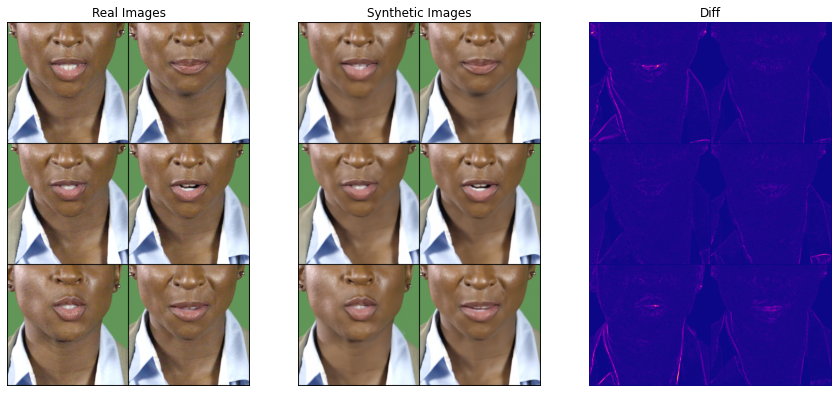


Epoch 651:

907it [01:51,  8.16it/s]
100it [00:12,  7.89it/s]


Epoch 652:


907it [01:53,  8.00it/s]
100it [00:13,  7.38it/s]


Epoch 653:


907it [01:52,  8.09it/s]
100it [00:13,  7.53it/s]


Epoch 654:


907it [01:49,  8.30it/s]
100it [00:14,  7.06it/s]



Epoch 655:

907it [01:51,  8.13it/s]
100it [00:13,  7.24it/s]


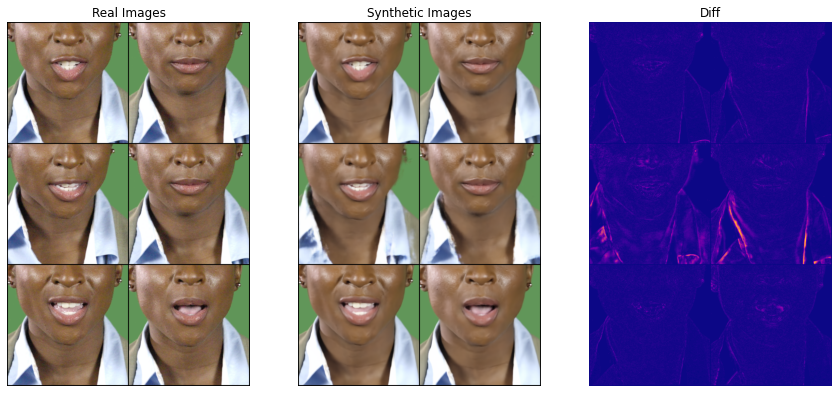


Epoch 656:

907it [01:51,  8.10it/s]
100it [00:13,  7.39it/s]


Epoch 657:


907it [01:49,  8.26it/s]
100it [00:13,  7.46it/s]


Epoch 658:


907it [01:51,  8.15it/s]
100it [00:13,  7.52it/s]


Epoch 659:


907it [01:48,  8.36it/s]
100it [00:13,  7.50it/s]



Epoch 660:

907it [01:49,  8.26it/s]
100it [00:13,  7.59it/s]


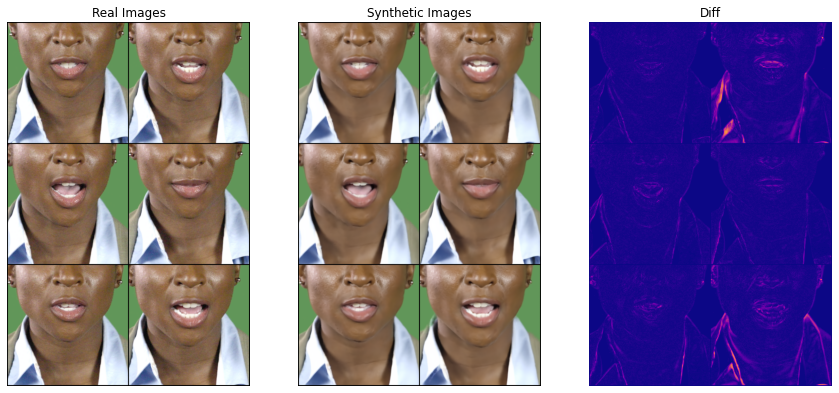


Epoch 661:

907it [01:50,  8.20it/s]
100it [00:13,  7.64it/s]


Epoch 662:


907it [01:50,  8.24it/s]
100it [00:12,  8.08it/s]


Epoch 663:


907it [01:51,  8.15it/s]
100it [00:12,  8.03it/s]


Epoch 664:


907it [01:51,  8.14it/s]
100it [00:12,  8.01it/s]



Epoch 665:

907it [01:49,  8.26it/s]
100it [00:13,  7.52it/s]


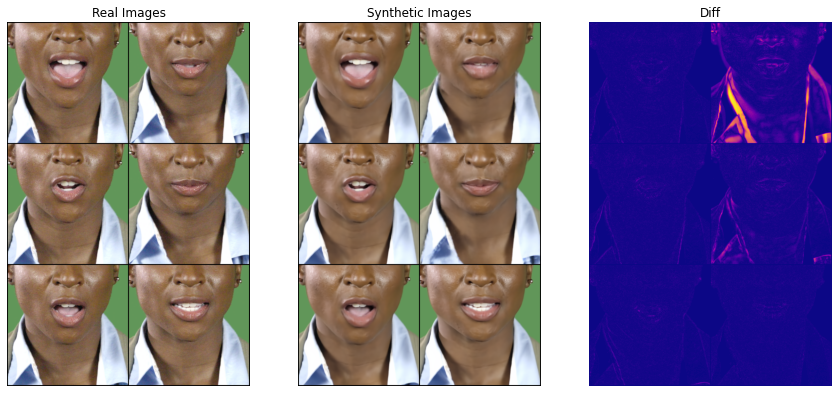


Epoch 666:

907it [01:50,  8.22it/s]
100it [00:13,  7.50it/s]


Epoch 667:


907it [01:48,  8.33it/s]
100it [00:13,  7.62it/s]


Epoch 668:


907it [01:50,  8.23it/s]
100it [00:13,  7.53it/s]


Epoch 669:


907it [01:49,  8.29it/s]
100it [00:13,  7.40it/s]



Epoch 670:

907it [01:48,  8.37it/s]
100it [00:13,  7.35it/s]


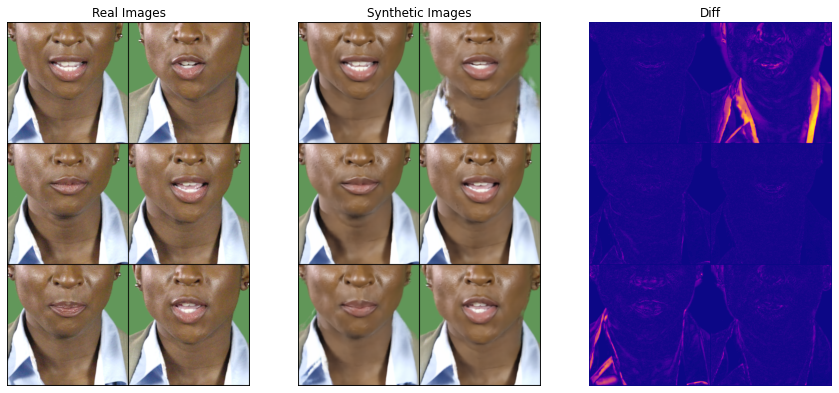


Epoch 671:

907it [01:49,  8.26it/s]
100it [00:14,  7.09it/s]


Epoch 672:


907it [01:50,  8.18it/s]
100it [00:13,  7.18it/s]


Epoch 673:


907it [01:51,  8.13it/s]
100it [00:13,  7.66it/s]


Epoch 674:


907it [01:52,  8.07it/s]
100it [00:12,  7.78it/s]



Epoch 675:

907it [01:52,  8.03it/s]
100it [00:12,  7.86it/s]


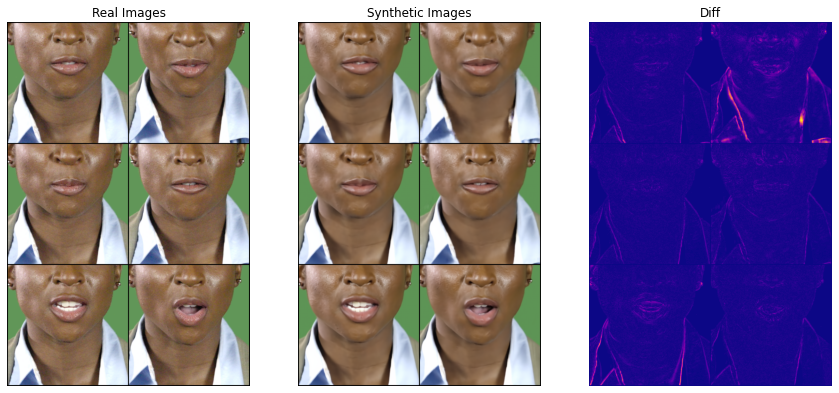


Epoch 676:

907it [01:50,  8.23it/s]
100it [00:13,  7.25it/s]


Epoch 677:


701it [01:25,  8.19it/s]


KeyboardInterrupt: ignored

In [ ]:
for epoch_idx in range(5000):
  print(flush=True)
  print(f"Epoch {epoch}:", end='', flush=True)

  cae.train()
  # mask_decoder.train()
  # discriminator.train()

  train_loss_sum = 0
  # train_mask_dec_loss_sum = 0
  # train_disc_loss_sum = 0

  start_time_train = time.time()

  for batch_idx, (item_idx_batch, voice_expr_batch, img_masked_batch, img_batch) in tqdm(enumerate(train_dataloader_cae), position=0, leave=True):
      b_size = img_batch.size(0)

      voice_expr_batch = voice_expr_batch.to(device)
      img_masked_batch = img_masked_batch.to(device)
      img_batch = img_batch.to(device)

      recon_img_batch, voice_encoding_batch, mask_encoding_batch = cae(voice_expr_batch, img_masked_batch)
      # mask_decoding_batch = mask_decoder(mask_encoding_batch.detach())

      recon_loss = reconstruction_loss_fn(recon_img_batch, img_batch).sum()  # Some loss funcs return a loss per sample.
      # mask_decode_loss = reconstruction_loss_fn(mask_decoding_batch, img_batch).sum()  # Some loss funcs return a loss per sample.

      # === Train the discriminator. ===
      # disc_opt.zero_grad()

      # fake_labels = torch.full((b_size,), fake_label, dtype=torch.float, device=device)
      # disc_fake_scores = discriminator(recon_img_batch.detach()).view(-1)
      # disc_fake_loss = disc_criterion(disc_fake_scores, fake_labels)
      # disc_fake_loss.backward()

      # real_labels = torch.full((b_size,), real_label, dtype=torch.float, device=device)
      # disc_real_scores = discriminator(img_batch.to(device)).view(-1)
      # disc_real_loss = disc_criterion(disc_real_scores, real_labels)
      # disc_real_loss.backward()

      # disc_opt.step()
      # train_disc_loss_sum += (disc_real_loss + disc_fake_loss).item() * b_size
      # === ===

      # === Train the mask decoder === #
      # mask_decoder_opt.zero_grad()

      # loss = mask_decode_loss # + ...
      # loss.backward()
      # mask_decoder_opt.step()

      # train_mask_dec_loss_sum += loss.item() * b_size
      # === === #

      # === Train the generator ===
      cae_opt.zero_grad()

      # real_labels = torch.full((b_size,), real_label, dtype=torch.float, device=device)
      # disc_score = discriminator(recon_img_batch).view(-1)
      # disc_loss = disc_criterion(disc_score, real_labels)

      loss = recon_loss # + disc_loss * discriminator_f
      loss.backward()
      cae_opt.step()

      train_loss_sum += loss.item() * b_size
      # === ===

      # print(f" disc_recon_score = {disc_score.mean()}", end='')
      # print(f" [disc_fake_scores, disc_real_scores = {disc_fake_scores.mean()}, {disc_real_scores.mean()}]")

  stop_time_train = time.time()
  samples_per_sec_train = len(train_dataloader_cae.dataset) / (stop_time_train - start_time_train)

  # train_mask_dec_loss = train_mask_dec_loss_sum / len(train_dataloader_cae.dataset)  # type: ignore
  # train_disc_loss = train_disc_loss_sum / len(train_dataloader_cae.dataset)  # type: ignore
  train_loss = train_loss_sum / len(train_dataloader_cae.dataset)  # type: ignore

  cae.eval()
  # mask_decoder.eval()
  # discriminator.eval()

  val_loss_sum = 0
  ref_loss_sum = 0

  start_time_val = time.time()

  for batch_idx, (item_idx_batch, voice_expr_batch, img_masked_batch, img_batch) in tqdm(enumerate(val_dataloader_cae), position=0, leave=True):
      b_size = img_batch.size(0)

      voice_expr_batch = voice_expr_batch.to(device)
      img_masked_batch = img_masked_batch.to(device)
      img_batch = img_batch.to(device)

      with torch.set_grad_enabled(False):
          recon_img_batch, voice_encoding_batch, mask_encoding_batch = cae(voice_expr_batch, img_masked_batch)
          # mask_decoding_batch = mask_decoder(mask_encoding_batch)

      recon_loss = reconstruction_loss_fn(recon_img_batch, img_batch).sum()  # Some loss funcs return a loss per sample.
      ref_loss = ref_loss_fn(recon_img_batch, img_batch).sum()  # Some loss funcs return a loss per sample.

      loss = recon_loss

      val_loss_sum += loss.item() * b_size
      ref_loss_sum += ref_loss.item() * b_size

  stop_time_val = time.time()
  samples_per_sec_val = len(val_dataloader_cae.dataset) / (stop_time_val - start_time_val)

  val_loss = val_loss_sum / len(val_dataloader_cae.dataset)  # type: ignore
  ref_loss = ref_loss_sum / len(val_dataloader_cae.dataset)  # type: ignore

  wandb.log({'train_loss': train_loss,
             'val_loss': val_loss,
             'ref_l1_loss': ref_loss,
             # 'train_disc_loss': train_disc_loss,
             # 'train_mask_dec_loss': train_mask_dec_loss,
             'samples_per_sec_train': samples_per_sec_train,
             'samples_per_sec_val': samples_per_sec_val,
             'epoch': epoch+1})

  if (epoch_idx % 50) == 0:
    clear_output()

  if ((epoch_idx % 5) == 0) or (epoch < 10):
    # Plot the real images from the current epoch's last validation batch.
    plt.figure(figsize=(20, 40))
    plt.subplot(1, 4, 1)
    plt.axis("off")
    plt.title("Real Images")
    plt.imshow(np.transpose(vutils.make_grid(img_batch[:6], nrow=2, padding=2, normalize=True).cpu().numpy(), (1,2,0)))

    # Plot the fake images from the current epoch's last validation batch.
    plt.subplot(1, 4, 2)
    plt.axis("off")
    plt.title("Synthetic Images")
    plt.imshow(np.transpose(vutils.make_grid(recon_img_batch[:6], nrow=2, padding=2, normalize=True).cpu().numpy(), (1,2,0)))

    # Plot the fake images from the current epoch's last validation batch.
    plt.subplot(1, 4, 3)
    plt.axis("off")
    plt.title("Diff")
    plt.imshow(np.sum(np.abs(np.transpose(vutils.make_grid(img_batch[:6] - recon_img_batch[:6], nrow=2, padding=2, normalize=False).cpu().numpy(), (1,2,0))), axis=2), cmap="plasma")

    # # Plot the fake images from the current epoch's last validation batch.
    # plt.subplot(1, 4, 4)
    # plt.axis("off")
    # plt.title("Mask Decode Images")
    # plt.imshow(np.transpose(vutils.make_grid(mask_decoding_batch[:6], nrow=2, padding=2, normalize=True).cpu().numpy(), (1,2,0)))

    plt.show()

  if ((epoch+1) % 5) == 0:
    # Save the trained networks.
    torch.save(cae.state_dict(), f"{artifact_root}/cae_epoch_{epoch+1}.pt")
    torch.save(cae_opt.state_dict(), f"{artifact_root}/cae_opt_epoch_{epoch+1}.pt")

    # torch.save(discriminator.state_dict(), f"{artifact_root}/disc_epoch_{epoch+1}.pt")
    # torch.save(disc_opt.state_dict(), f"{artifact_root}/disc_opt_epoch_{epoch+1}.pt")

  epoch += 1


In [ ]:
wandb.finish()

In [ ]:
# Plot the real images from the current epoch's last validation batch.
plt.figure(figsize=(20, 40))
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(img_batch[:6], nrow=2, padding=2, normalize=True).cpu().numpy(), (1,2,0)))

# Plot the fake images from the current epoch's last validation batch.
plt.subplot(1, 3, 2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(vutils.make_grid(recon_img_batch[:6], nrow=2, padding=2, normalize=True).cpu().numpy(), (1,2,0)))

# Plot the fake images from the current epoch's last validation batch.
plt.subplot(1, 3, 3)
plt.axis("off")
plt.title("Diff")
plt.imshow(np.sum(np.abs(np.transpose(vutils.make_grid(img_batch[:6] - recon_img_batch[:6], nrow=2, padding=2, normalize=False).cpu().numpy(), (1,2,0))), axis=2), cmap="plasma")

plt.show()


In [ ]:
# Save the trained networks.
torch.save(cae.state_dict(), f"{artifact_root}/cae_epoch_final.pt")
torch.save(cae_opt.state_dict(), f"{artifact_root}/cae_opt_epoch_final.pt")
# torch.save(discriminator.state_dict(), f"{artifact_root}/disc_epoch_final.pt")
# torch.save(disc_opt.state_dict(), f"{artifact_root}/disc_opt_epoch_final.pt")
